# 6.3.1 LTI假设与Laplace表示

## 学习目标与先修知识

能检验线性时不变（linear time-invariant，LTI）假设，区分零输入响应（zero-input response）与零状态响应（zero-state response）；从一侧 Laplace 变换（unilateral Laplace transform）的初值（initial condition）项推导传递函数（transfer function），解释收敛域（region of convergence，ROC）和极点（pole）的含义。

先修：6.2 的叠加、卷积与复指数，2.3 的一阶方程解析解（analytical solution），3.3 的状态（state）表示。[复习一阶连续模型](../../02-系统随时间演化/03-连续时间与一阶微分方程/02-平衡位置与靠近速度.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

向一个理想组织室持续输入（input）可清除物质，为什么“把输入加倍”有时并不会把测到的总量加倍？起始时已经存在的物质和新输入的物质，在方程中应怎样分别追踪？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
k, t, initial = 0.4, 2.0, 3.0
rows=[]
for input_rate in [0.0, 1.0, 2.0]:
    amount=initial*math.exp(-k*t)+input_rate*(1-math.exp(-k*t))/k
    rows.append((input_rate, amount))
display(Markdown(show_table(['输入 / U·T⁻¹','时刻 2 T 的总量 / U'],rows)))

| 输入 / U·T⁻¹ | 时刻 2 T 的总量 / U |
| --- | --- |
| 0 | 1.34799 |
| 1 | 2.72466 |
| 2 | 4.10134 |

## 模型假设

状态 $x(t)$ 是所追踪物质总量（tracked amount），单位 U；输入 $u(t)$ 是流入率，单位 U/T；清除系数（elimination rate constant） $k\ge0$，单位 $1/T$。模型（model）为 $\dot x=-kx+u$，观测（observation）直接等于 $x$，初值 $x(0)=x_0$。本节没有饱和、延迟（delay）、测量误差或时变系数；示例 $k=0.4/T$、$x_0=3$ U，都是便于计算的教学参数（parameter）。

讨论总量时用非负初值与输入。检验线性时允许带符号的小扰动，或将数学系统扩展到实数输入；负扰动表示相对参考水平的减少。输入在 $t<0$ 为零，因果性（causality）表示输出（output）不依赖未来输入。输入分段连续，起点无瞬时脉冲，因此 $x(0^-)=x(0^+)=x_0$。

## 数学解释与推导

### 叠加要先说明起点

由积分因子得到
$$x(t)=\underbrace{x_0e^{-kt}}_{\text{零输入响应}}+\underbrace{\int_0^t e^{-k(t-\tau)}u(\tau)\,d\tau}_{\text{零状态响应}}.$$
零输入响应来自初值；零状态响应来自初始为零时的输入。后者满足叠加：输入 $c_1u_1+c_2u_2$ 得到 $c_1x_1+c_2x_2$，因为积分对加法和数乘都保持。核只依赖 $t-\tau$，对从静止开始的因果信号延迟输入，输出同样延迟，这是时不变性（time invariance）。

**固定非零初值时，输入到总输出的映射是仿射映射（affine map），不是线性映射（linear map）。** 输入为零时仍有 $x_0e^{-kt}$；加两份完整响应会把初值响应算两次。系统方程仍然是线性的，若把初值与输入一起按相同比例叠加则成立。饱和清除 $V_{max}x/(K+x)$（$V_{max}>0$ 单位 U/T、$K>0$ 单位 U）破坏线性；$k(t)x$ 通常保持线性但破坏时不变性。局部线性近似不等于原系统全局 LTI。

### 用积分把微分改成代数

令复数（complex number） $s=\sigma+i\omega$，单位 $1/T$。一侧变换定义为
$$X(s)=\int_0^\infty x(t)e^{-st}\,dt.$$
它只在积分收敛的 $s$ 上有意义。例：$e^{-kt}$ 的变换是 $1/(s+k)$，ROC 为 $\operatorname{Re}(s)>-k$；分式不应脱离收敛条件单独理解。

分部积分，在 $x(t)e^{-st}\to0$ 的收敛域内给出
$$\mathcal L\{\dot x\}=[xe^{-st}]_0^\infty+sX=sX-x_0.$$
代回状态方程得
$$X(s)=\frac{x_0}{s+k}+\frac{1}{s+k}U(s).$$
**零初值时** $H(s)=X(s)/U(s)=1/(s+k)$ 是传递函数；$x_0/(s+k)$ 不是输入传递函数的一部分。$H$ 的单位为 T。注意变换包含时间积分：$U(s)$ 的单位是 U，$X(s)$ 的单位是 U·T，所以 $X=HU$ 的单位一致。回到时域，恒定流率（flow rate）与直流增益（gain） $H(0)=1/k$ 相乘才得到稳态总量 U（要求 k>0）。

零点（zero）是约去公共因子后使分子为零的位置；极点使分母为零。本模型只有极点 $s=-k$，没有有限零点。零状态脉冲响应（impulse response）为 $h(t)=e^{-kt}$（$t\ge0$），因此 $k>0$ 时 $\int_0^\infty|h(t)|dt=1/k<\infty$，有界输入产生有界输出，即 BIBO 稳定性（bounded-input bounded-output stability）。$k=0$ 为积分器，恒定非零输入使总量线性增加，不具有该性质。对有限维、因果、分子次数不高于分母次数的有理传递函数，约去公共因子后可通过极点是否在左半平面判断 BIBO 稳定；一般状态空间（state space）还须另外检查内部模态（mode），不能用被约消的传函看见所有内部状态。

对常量输入 $u$，零状态项为 $u(1-e^{-kt})/k$；$k\to0$ 时连续延伸为 $ut$。当 $k>0$ 且 $u\ne0$，完整阶跃响应趋于常数，其一侧变换 ROC 通常为 $\operatorname{Re}(s)>0$；不要把脉冲响应的 ROC 原样当作所有输入响应的 ROC。

## 核心实现

把每个量的计算写在本节，返回普通数值与列表；先检查定义，再用独立关系核对结果。

In [3]:
def continuous_components(k: float, input_rate: float, initial: float,
                          times: list[float]) -> tuple[list[float], list[float]]:
    if k < 0 or any(t < 0 for t in times):
        raise ValueError('清除系数与时间须非负')
    zero_input, zero_state = [], []
    for t in times:
        decay = math.exp(-k*t)
        zero_input.append(initial*decay)
        # expm1 在 k*t 很小时避免 1-exp(-k*t) 相减损失精度。
        gain = t if k == 0 else -math.expm1(-k*t)/k
        zero_state.append(input_rate*gain)
    return zero_input, zero_state

## 对照实验

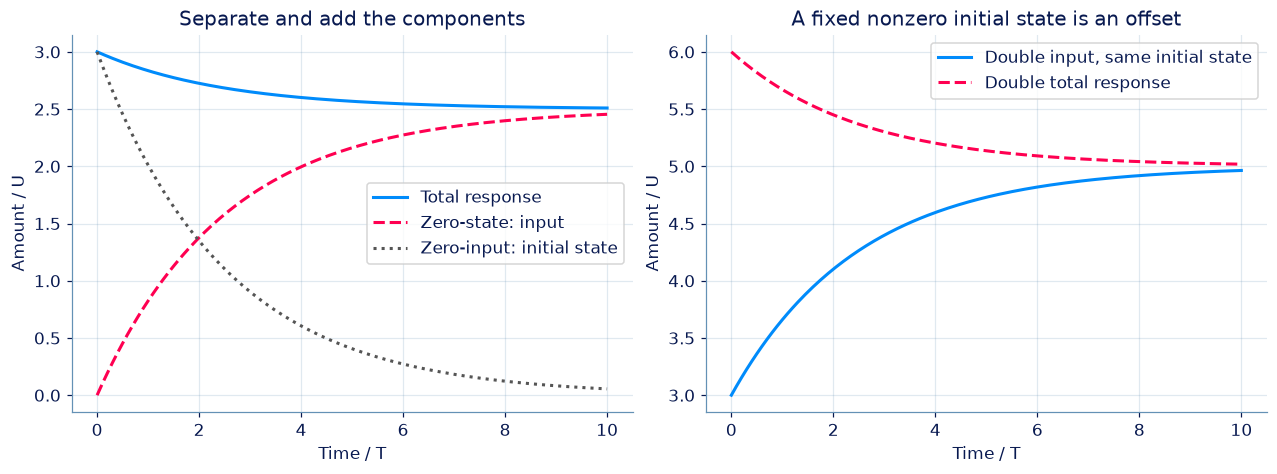

In [4]:
times=np.linspace(0,10,201)
zero_input,zero_state=map(np.asarray,continuous_components(0.4,1.0,3.0,times.tolist()))
total=zero_input+zero_state
fig,axes=plt.subplots(1,2,figsize=(11.5,4.2))
axes[0].plot(times,total,color=BLUE,label='Total response')
axes[0].plot(times,zero_state,color=PINK,ls='--',label='Zero-state: input')
axes[0].plot(times,zero_input,color=GRAY,ls=':',label='Zero-input: initial state')
axes[0].set(xlabel='Time / T',ylabel='Amount / U',title='Separate and add the components')
axes[0].legend()
zi,zs=continuous_components(0.4,2.0,3.0,times.tolist())
axes[1].plot(times,np.array(zi)+zs,color=BLUE,label='Double input, same initial state')
axes[1].plot(times,2*total,color=PINK,ls='--',label='Double total response')
axes[1].set(xlabel='Time / T',ylabel='Amount / U',title='A fixed nonzero initial state is an offset')
axes[1].legend()
plt.show()

## 结果解释

左图三条线的关系由解的分解得到；右图两条线的差恰好是一份初值响应，并会随时间衰减。这个差异不表示方程“变成非线性”，而是检验叠加时没有同步处理初值。改变 k 影响极点和衰减速度，改变初值只影响已有物质的响应。观察：[时域与极点联动](http://127.0.0.1:8000/chapters/06-03-LTI%20系统、Laplace%20与%20Z%20变换/explore/)。

### 独立核对与边界

In [5]:
zi,zs=continuous_components(0.4,1.0,3.0,[0.,2.,5.])
assert zi[0]==3 and zs[0]==0
assert np.allclose(np.array(zi)+zs,2.5+0.5*np.exp(-0.4*np.array([0.,2.,5.])))
zi0,zs0=continuous_components(0.,2.,3.,[0.,1.,2.])
assert zi0==[3.,3.,3.] and zs0==[0.,2.,4.]
# 把核的积分作为独立参照，核对常量输入的零状态响应。
fine=np.linspace(0,2,20001)
integral=np.trapezoid(np.exp(-0.4*(2-fine)),fine)
assert abs(zs[1]-integral)<1e-8
display(Markdown('初值、零清除极限与独立积分核对均通过。'))

初值、零清除极限与独立积分核对均通过。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：将初态与输入的作用分开

系统 dA/dt=input_rate−k*A。分别返回零输入响应（zero-input response）与零状态响应（zero-state response）；两者相加得到完整响应。

**函数与代码模板**

```python
def solve(
    k: float,
    input_rate: float,
    initial: float,
    times: list[float],
) -> tuple[list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `input_rate` | `float` | t≥0的恒定输入（input）流率（flow rate）。 | U/T |
| `initial` | `float` | t=0初始所追踪物质总量（tracked amount）。 | U |
| `times` | `list[float]` | 求值时刻。 | T |

**返回值**

按以下顺序返回元组：(zero_input, zero_state)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `zero_input` | `list[float]` | 由初态产生、无输入时的响应。 | U |
| `zero_state` | `list[float]` | 从零初态由恒定输入产生的响应。 | U |

**计算规则**

零输入=initial*exp(−kt)；k>0时零状态（state）=input_rate*(1−exp(−kt))/k，k=0时为input_rate*t。推荐expm1处理很小kt。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0≤k≤2；0≤input_rate,initial≤20；0—50个时刻，各0≤t≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 清除系数（elimination rate constant）。 | 0.5 | 1/T |
| input_rate | t≥0的恒定输入（input）流率（flow rate）。 | 2 | U/T |
| initial | t=0初始所追踪物质总量（tracked amount）。 | 3 | U |
| times | 求值时刻。 | [0.0, 2.0, 4.0] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.5
input_rate = 2.0
initial = 3.0
times = [0.0, 2.0, 4.0]

result = solve(k, input_rate, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| zero_input | 由初态产生、无输入时的响应。 | [3.0, 1.103638323514327, 0.4060058497098381] | U |
| zero_state | 从零初态由恒定输入产生的响应。 | [0.0, 2.5284822353142307, 3.458658867053549] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([3.0,
                    1.103638323514327,
                    0.4060058497098381],
                   [0.0,
                    2.5284822353142307,
                    3.458658867053549])
```

**样例解释**

t=0时两部分为3和0 U；t=2时为3e⁻¹和4(1−e⁻¹) U。非零初态不能藏进只描述零状态响应的传递函数（transfer function）。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：将初态与输入的作用分开](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-response-components)

### 第 2 题 · 单项选择题：导数变换遗漏了哪一项

对t≥0的一侧Laplace变换，A(0)=A0，dA/dt=u−kA。哪项正确？

- **A.** 所有非线性模型（model）都能用同一固定G(s)描述。
- **B.** (s+k)A(s)=U(s)+A0。
- **C.** (s+k)A(s)=U(s)，任何初态都成立。
- **D.** A0只会改变极点（pole）位置。

[作答：导数变换遗漏了哪一项](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-laplace-initial)

### 第 3 题 · 多项选择题：固定非零初态的映射是否线性

系统动力学 dA/dt=u−kA 为线性方程，但把固定A0=3的u→A映射称为线性输入（input）输出（output）算子。哪些正确？

- **A.** 固定非零初态时，零输入通常仍有非零输出。
- **B.** 该映射一般是仿射（affine）的，零状态（state）部分才满足输入叠加。
- **C.** 把初态也作为可缩放输入的一部分可以恢复联合线性描述。
- **D.** 方程线性就允许忽略一切初态。

[作答：固定非零初态的映射是否线性](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-linear-map-initial)

### 第 4 题 · 多项选择题：极点与收敛域说明什么

因果核 h(t)=exp(−kt)，t≥0，k>0。哪些正确？

- **A.** 同一有理式无需收敛域（region of convergence，ROC）就唯一决定所有双侧时间信号。
- **B.** 在该因果模型（model）中极点（pole）−k位于左半平面，核绝对可积。
- **C.** k=0时仍具有相同的有界输入（input）有界输出（output）稳定性。
- **D.** 其Laplace变换为1/(s+k)，收敛域Re(s)>−k。

[作答：极点与收敛域说明什么](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-roc-causal)

### 第 5 题 · 单项选择题：线性与时不变哪个失效

考虑清除模型（model） dA/dt=u−k(t)A 与 dA/dt=u−Vmax*A/(K+A)。其中k(t)单位1/T，Vmax>0单位U/T，K>0单位U，A≥0。哪项正确？

- **A.** 只要有清除就必是LTI。
- **B.** 在某一点线性化（linearization）即可保证所有初态都用同一模型。
- **C.** 前者一般线性但时变，后者一般非线性。
- **D.** 前者一定非线性，后者一定线性。

[作答：线性与时不变哪个失效](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-lti-failure)

**进一步阅读**

[MIT 6.003 讲义](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/pages/lecture-notes/)第 6、8、9 讲：Laplace 表示、卷积及频率响应；本节单室分解与边界例由课程构造。